In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
data = pd.read_csv("recursos_humanos.csv")


In [29]:
print(data.info())
print(data['left'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB
None
left
0    11428
1     3571
Name: count, dtype: int64


In [30]:
data = pd.get_dummies(data, columns=['sales', 'salary'], drop_first=True)


In [31]:
X = data.drop('left', axis=1)
y = data['left']

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [51]:
accuracies = []
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

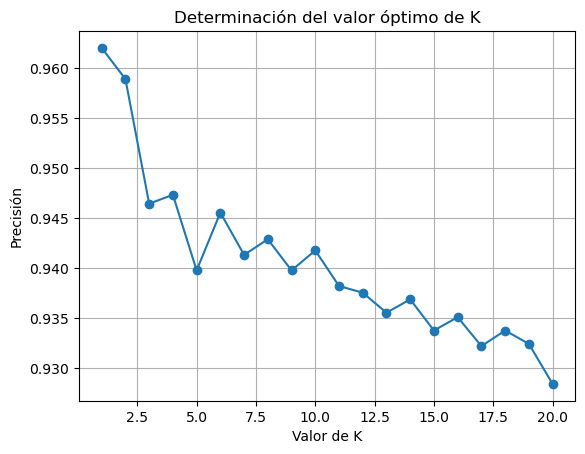

In [52]:
k_values = range(1, 21)
plt.plot(k_values, accuracies, marker='o')
plt.xlabel("Valor de K")
plt.ylabel("Precisión")
plt.title("Determinación del valor óptimo de K")
plt.grid()
plt.show()

In [53]:
optimal_k = k_values[np.argmax(accuracies)]
print(f"El valor óptimo de K es: {optimal_k}")

El valor óptimo de K es: 1


El resultado de 
k=1 indica que el modelo funciona mejor al considerar solo el vecino más cercano, aunque esto puede hacerlo más sensible al ruido en los datos.

In [54]:
knn_optimal = KNeighborsClassifier(n_neighbors=optimal_k)
knn_optimal.fit(X_train, y_train)
y_pred_optimal = knn_optimal.predict(X_test)


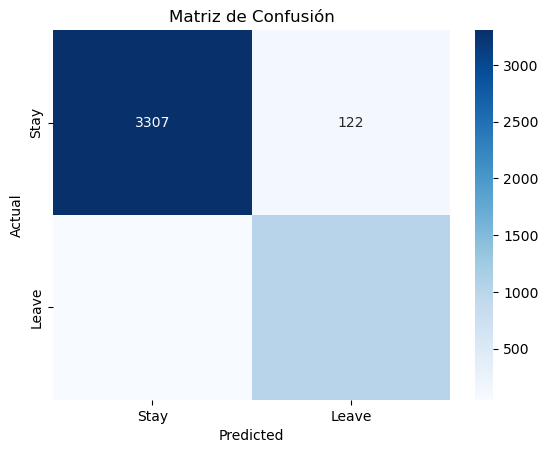

In [55]:
conf_matrix = confusion_matrix(y_test, y_pred_optimal)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Stay", "Leave"], yticklabels=["Stay", "Leave"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Matriz de Confusión")
plt.show()

True Negatives (TN): 3307 empleados que se quedan fueron correctamente clasificados.
True Positives (TP): 122 empleados que se van fueron correctamente clasificados.
False Positives (FP): Casi no se obrserva empleados clasificados como "se van" pero en realidad "se quedan", lo cual es positivo.
False Negatives (FN): Casi no se observan empleados clasificados como "se quedan" pero en realidad "se van", lo cual es positivo.

In [45]:
print(f"Precisión con K={optimal_k}: {accuracy_score(y_test, y_pred_optimal):.2f}")

Precisión con K=1: 0.95


In [46]:
y_pred_proba = knn_optimal.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

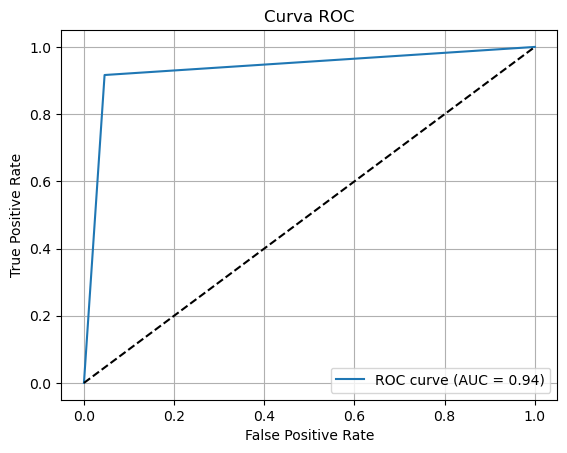

In [47]:
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend(loc="lower right")
plt.grid()
plt.show()

In [48]:
print(f"El área bajo la curva (AUC) es: {roc_auc:.2f}")

El área bajo la curva (AUC) es: 0.94


El AUC de 0.94 es excelente y confirma que el modelo tiene un gran rendimiento en separar las clases (empleados que se quedan vs. empleados que se van), incluso en el conjunto de prueba.
